<a href="https://colab.research.google.com/github/alstj003/2025-1-A-myclass-BDA/blob/main/20242884.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 32.6 MB/s eta 0:00:00


In [20]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
%config InlineBackend.figure_format = 'retina'

In [22]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

-> csv 파일 읽기

In [23]:
df = pd.read_csv('house.csv')  # 파일명 확인 후 수정 필요
df.head()

,시도명,시군구명,읍면동명,계,남자,여자,0세남자,1세남자,2세남자,3세남자,...,101세여자,102세여자,103세여자,104세여자,105세여자,106세여자,107세여자,108세여자,109세여자,110세이상 여자
0,서울특별시,종로구,청운효자동,1918,707,1211,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,서울특별시,종로구,사직동,2337,897,1440,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,서울특별시,종로구,삼청동,538,254,284,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,서울특별시,종로구,부암동,1681,699,982,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,서울특별시,종로구,평창동,2275,866,1409,0,0,0,0,...,2,1,1,0,0,0,0,0,0,0


-> csv 파일에서 서울특별시만 분류

In [24]:
seoul_df = df[df['시도명'] == '서울특별시']
seoul_df

,시도명,시군구명,읍면동명,계,남자,여자,0세남자,1세남자,2세남자,3세남자,...,101세여자,102세여자,103세여자,104세여자,105세여자,106세여자,107세여자,108세여자,109세여자,110세이상 여자
0,서울특별시,종로구,청운효자동,1918,707,1211,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,서울특별시,종로구,사직동,2337,897,1440,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,서울특별시,종로구,삼청동,538,254,284,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,서울특별시,종로구,부암동,1681,699,982,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,서울특별시,종로구,평창동,2275,866,1409,0,0,0,0,...,2,1,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,서울특별시,강동구,성내제2동,8107,3978,4129,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
422,서울특별시,강동구,성내제3동,4774,2235,2539,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
423,서울특별시,강동구,길동,11251,5281,5970,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
424,서울특별시,강동구,둔촌제1동,2012,887,1125,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


-> 서울특별시 남녀 비율 계산

In [25]:
seoul_df['지역'] = seoul_df['시군구명'] + ' ' + seoul_df['읍면동명']

<ipython-input-25-c05a6fa91cab>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  seoul_df['지역'] = seoul_df['시군구명'] + ' ' + seoul_df['읍면동명']


In [26]:
# 총 인구 컬럼 추가 (남자 + 여자)
seoul_df['계'] = seoul_df['남자'] + seoul_df['여자']

<ipython-input-26-211837a799c4>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  seoul_df['계'] = seoul_df['남자'] + seoul_df['여자']


In [27]:
# 남자와 여자 인구 총합 계산
male_total = seoul_df['남자'].sum()
female_total = seoul_df['여자'].sum()

In [28]:
# 비율 계산
total = male_total + female_total
male_ratio = male_total / total
female_ratio = female_total / total

In [29]:
# 결과 확인 (소수점 3자리)
print(gender_by_district[['남자비율', '여자비율']].round(3))

        남자비율   여자비율
시도명                
서울특별시  0.476  0.524


-> 서울특별시 남녀 인구 비율 원그래프 시각화

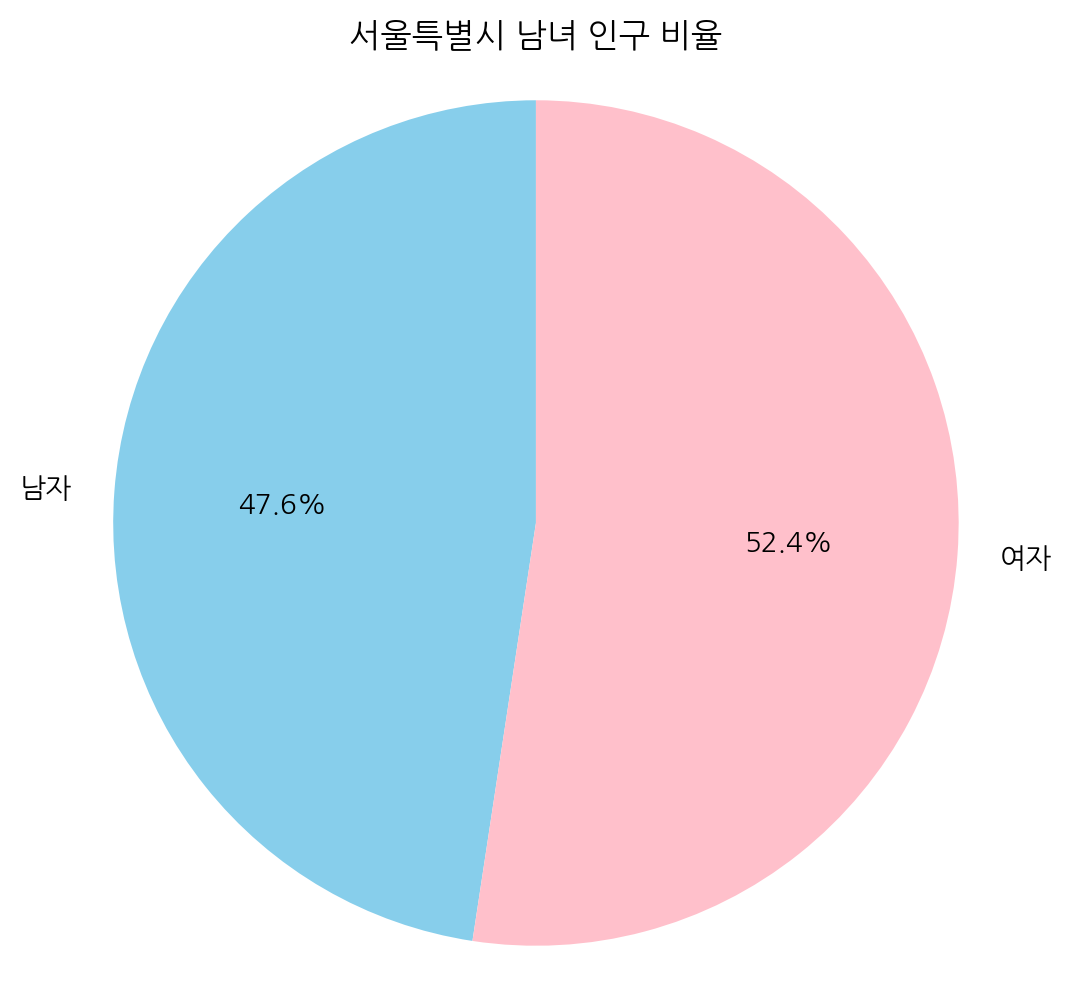

In [30]:
# 원 그래프 시각화
plt.figure(figsize=(6,6))
plt.pie([male_ratio, female_ratio],
        labels=['남자', '여자'],
        autopct='%.1f%%',
        startangle=90,
        colors=['skyblue', 'pink'])
plt.title('서울특별시 남녀 인구 비율')
plt.axis('equal')  # 원형 유지
plt.show()

-> 서울특별시에서 1인 가구 수가 가장 많은 지역 출력

In [31]:
# 서울특별시 데이터만 필터링
seoul_df = df[df["시도명"] == "서울특별시"]

# '계' 값이 가장 큰 행의 인덱스 찾기
max_index = seoul_df["계"].idxmax()

# 해당 행의 정보 추출
top_seoul = seoul_df.loc[max_index, ["시군구명", "읍면동명", "계"]]

# 결과 출력
print("✅ 서울특별시에서 1인 가구 수가 가장 많은 지역:")
print(top_seoul)

✅ 서울특별시에서 1인 가구 수가 가장 많은 지역:
시군구명      관악구
읍면동명      청룡동
계       18369
Name: 324, dtype: object


-> 전체 연령대의 1인 가구수 산점도 그래프 시각화

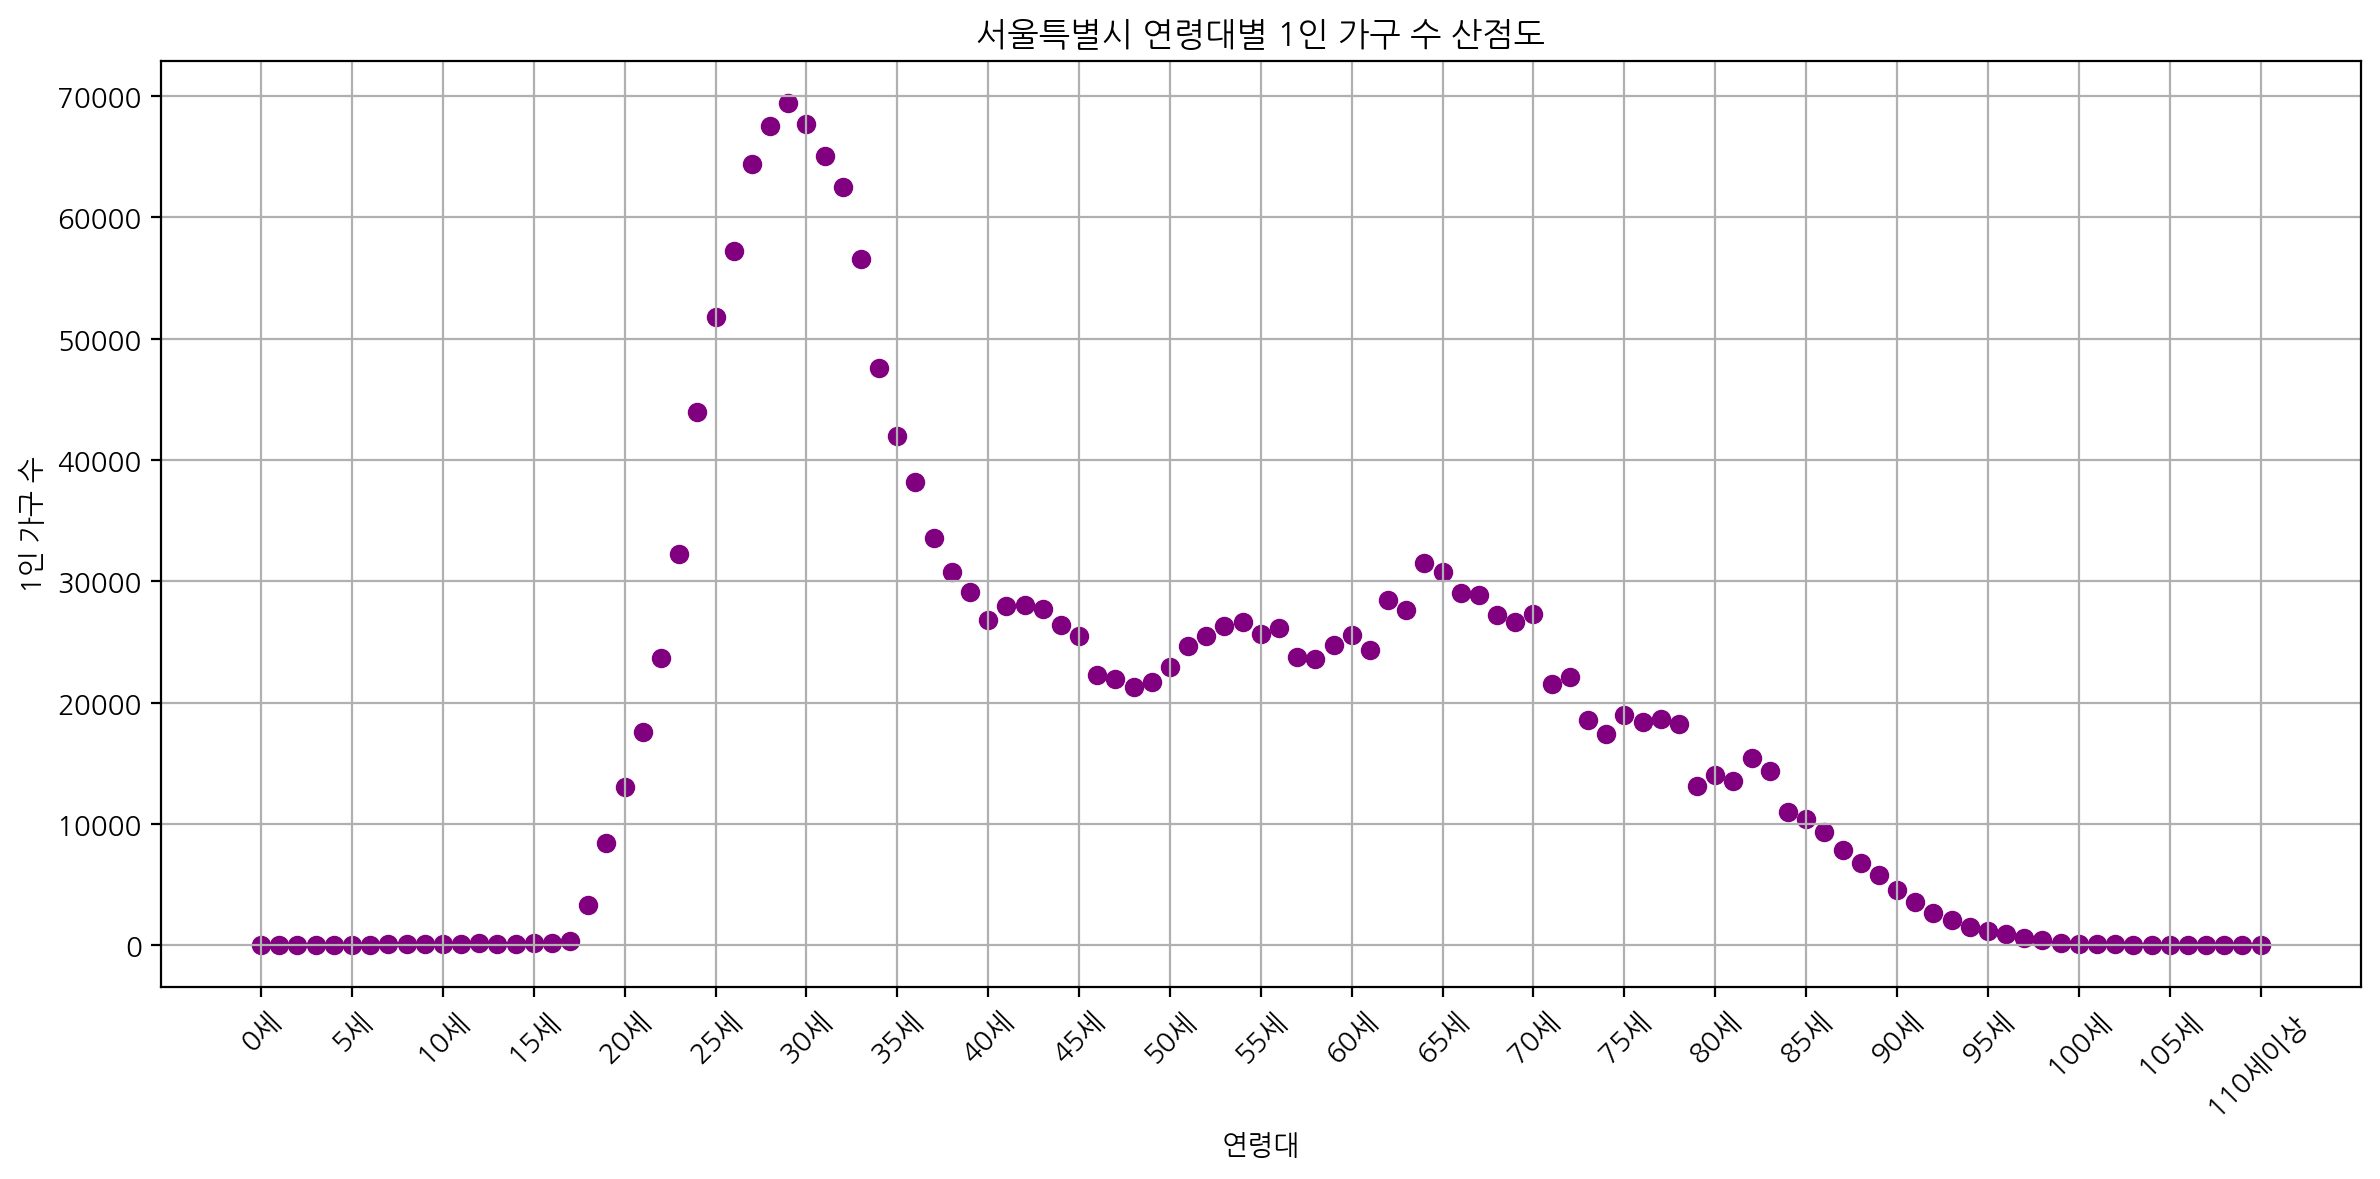

In [36]:
import matplotlib.pyplot as plt

# 서울특별시 데이터만 필터링
seoul_df = df[df["시도명"] == "서울특별시"]

# 연령대별 남자/여자 컬럼 추출
age_columns = [col for col in df.columns if '세' in col and ('남자' in col or '여자' in col)]

# 중복 없는 연령대 이름만 추출 (예: '20세', '25세', ..., '100세 이상')
age_groups = list(set(col[:-2] for col in age_columns))

# 연령대 정렬용 숫자 추출 함수 정의
def age_to_int(age):
    if '이상' in age:
        return int(age.replace('세이상', '').replace('세 이상', '').replace('세이 상', '').replace('세 이상', ''))
    else:
        return int(age.replace('세', ''))

# 정렬
age_groups_sorted = sorted(age_groups, key=age_to_int)

# 연령대별 남+여 합계 구하기
age_totals = []
for age in age_groups_sorted:
    male_col = age + '남자'
    female_col = age + '여자'
    if male_col in seoul_df.columns and female_col in seoul_df.columns:
        total = seoul_df[male_col].sum() + seoul_df[female_col].sum()
        age_totals.append(total)

# 산점도 그리기
plt.figure(figsize=(12, 6))
plt.scatter(age_groups_sorted, age_totals, color='purple')
plt.title('서울특별시 연령대별 1인 가구 수 산점도')
plt.xlabel('연령대')
plt.ylabel('1인 가구 수')

# x축 레이블 일부만 표시
plt.xticks(ticks=range(0, len(age_groups_sorted), 5),
           labels=age_groups_sorted[::5],
           rotation=45,
           fontsize=10)

plt.grid(True)
plt.tight_layout()
plt.show()

-> 가장 많은 1인 가구 수와 그에 해당하는 연령대 구하기

In [53]:
max_index = age_totals.index(max(age_totals))
most_common_age = age_groups_sorted[max_index]
most_common_total = age_totals[max_index]

print(f"✅ 서울특별시에서 1인 가구 수가 가장 많은 연령대는 '{most_common_age}'이며, 총 {most_common_total}가구입니다.")

✅ 서울특별시에서 1인 가구 수가 가장 많은 연령대는 '64세'이며, 총 12271가구입니다.


-> csv 파일에서 인천광역시만 분류

In [40]:
incheon_df = df[df['시도명'] == '인천광역시']
incheon_df

,시도명,시군구명,읍면동명,계,남자,여자,0세남자,1세남자,2세남자,3세남자,...,101세여자,102세여자,103세여자,104세여자,105세여자,106세여자,107세여자,108세여자,109세여자,110세이상 여자
784,인천광역시,중구,연안동,1577,999,578,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
785,인천광역시,중구,신포동,1319,716,603,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
786,인천광역시,중구,신흥동,2963,1627,1336,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
787,인천광역시,중구,도원동,1069,559,510,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
788,인천광역시,중구,율목동,1101,611,490,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,인천광역시,옹진군,덕적면,789,460,329,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
940,인천광역시,옹진군,영흥면,2174,1390,784,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
941,인천광역시,옹진군,자월면,369,210,159,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
942,인천광역시,옹진군,자월면이작출장소,128,70,58,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


-> 인천광역시 남녀 비율 계산

In [42]:
incheon_df['지역'] = incheon_df['시군구명'] + ' ' + incheon_df['읍면동명']

<ipython-input-42-7425aef44e8e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  incheon_df['지역'] = incheon_df['시군구명'] + ' ' + incheon_df['읍면동명']


In [43]:
# 총 인구 컬럼 추가 (남자 + 여자)
incheon_df['계'] = incheon_df['남자'] + incheon_df['여자']

<ipython-input-43-b97141f5631a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  incheon_df['계'] = incheon_df['남자'] + incheon_df['여자']


In [44]:
# 남자와 여자 인구 총합 계산
male_total = incheon_df['남자'].sum()
female_total = incheon_df['여자'].sum()

In [46]:
# 비율 계산
total = male_total + female_total
male_ratio = male_total / total
female_ratio = female_total / total

In [49]:
print("✅ 인천광역시 남녀 비율")
print(f"남자 비율: {male_ratio:.3f}")
print(f"여자 비율: {female_ratio:.3f}")

✅ 인천광역시 남녀 비율
남자 비율: 0.528
여자 비율: 0.472


-> 인천광역시 남녀 비율 원그래프 시각화

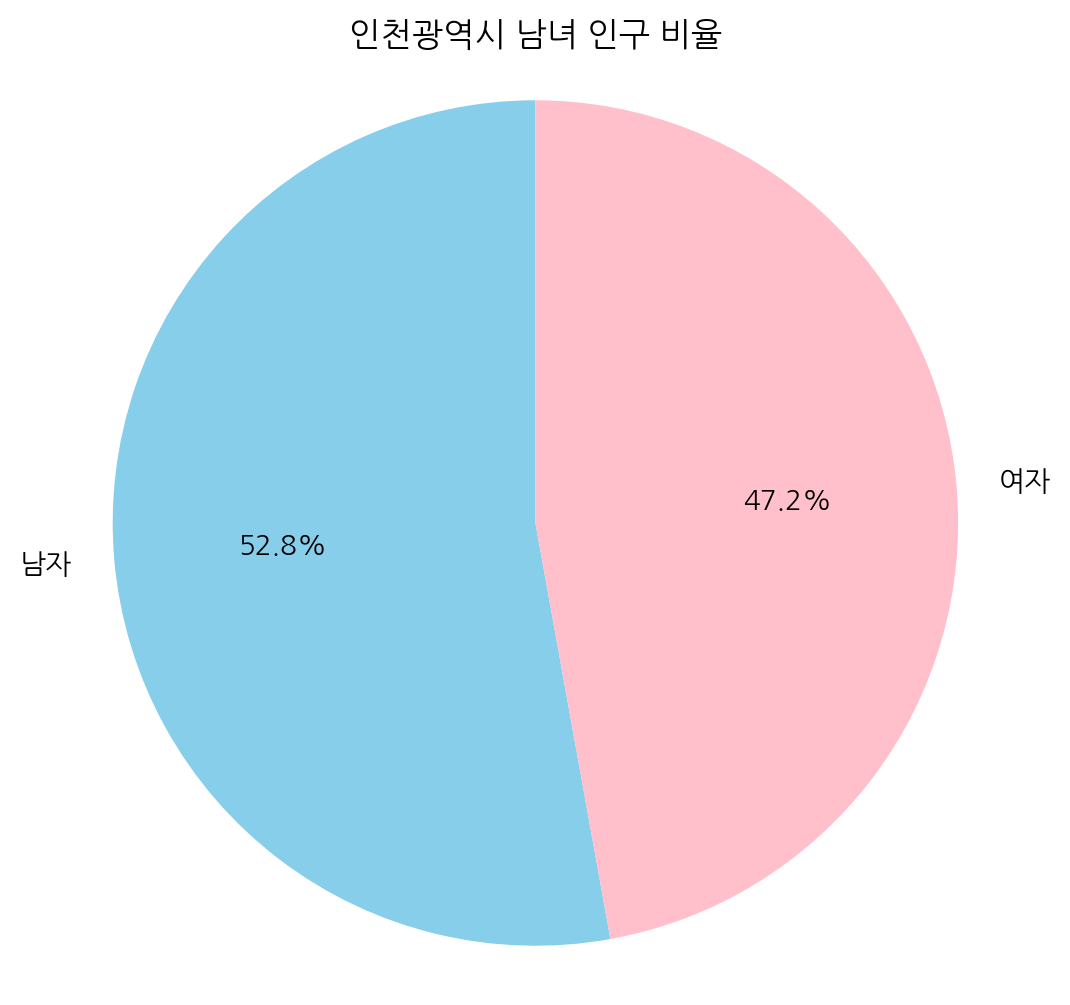

In [50]:
# 원 그래프 시각화
plt.figure(figsize=(6,6))
plt.pie([male_ratio, female_ratio],
        labels=['남자', '여자'],
        autopct='%.1f%%',
        startangle=90,
        colors=['skyblue', 'pink'])
plt.title('인천광역시 남녀 인구 비율')
plt.axis('equal')  # 원형 유지
plt.show()

-> 인천광역시에서 1인 가구 수가 가장 많은 지역 출력

In [64]:
# 인천광역시 데이터만 필터링
busan_df = df[df["시도명"] == "인천광역시"]

# '계' 값이 가장 큰 행의 인덱스 찾기
max_index = seoul_df["계"].idxmax()

# 해당 행의 정보 추출
top_incheon = incheon_df.loc[max_index, ["시군구명", "읍면동명", "계"]]

# 결과 출력
print("✅ 인천광역시에서 1인 가구 수가 가장 많은 지역:")
print(top_incheon)

✅ 인천광역시에서 1인 가구 수가 가장 많은 지역:
시군구명       중구
읍면동명      운서동
계       14626
Name: 794, dtype: object


-> 전체 연령대의 1인 가구수 산점도 그래프 시각화

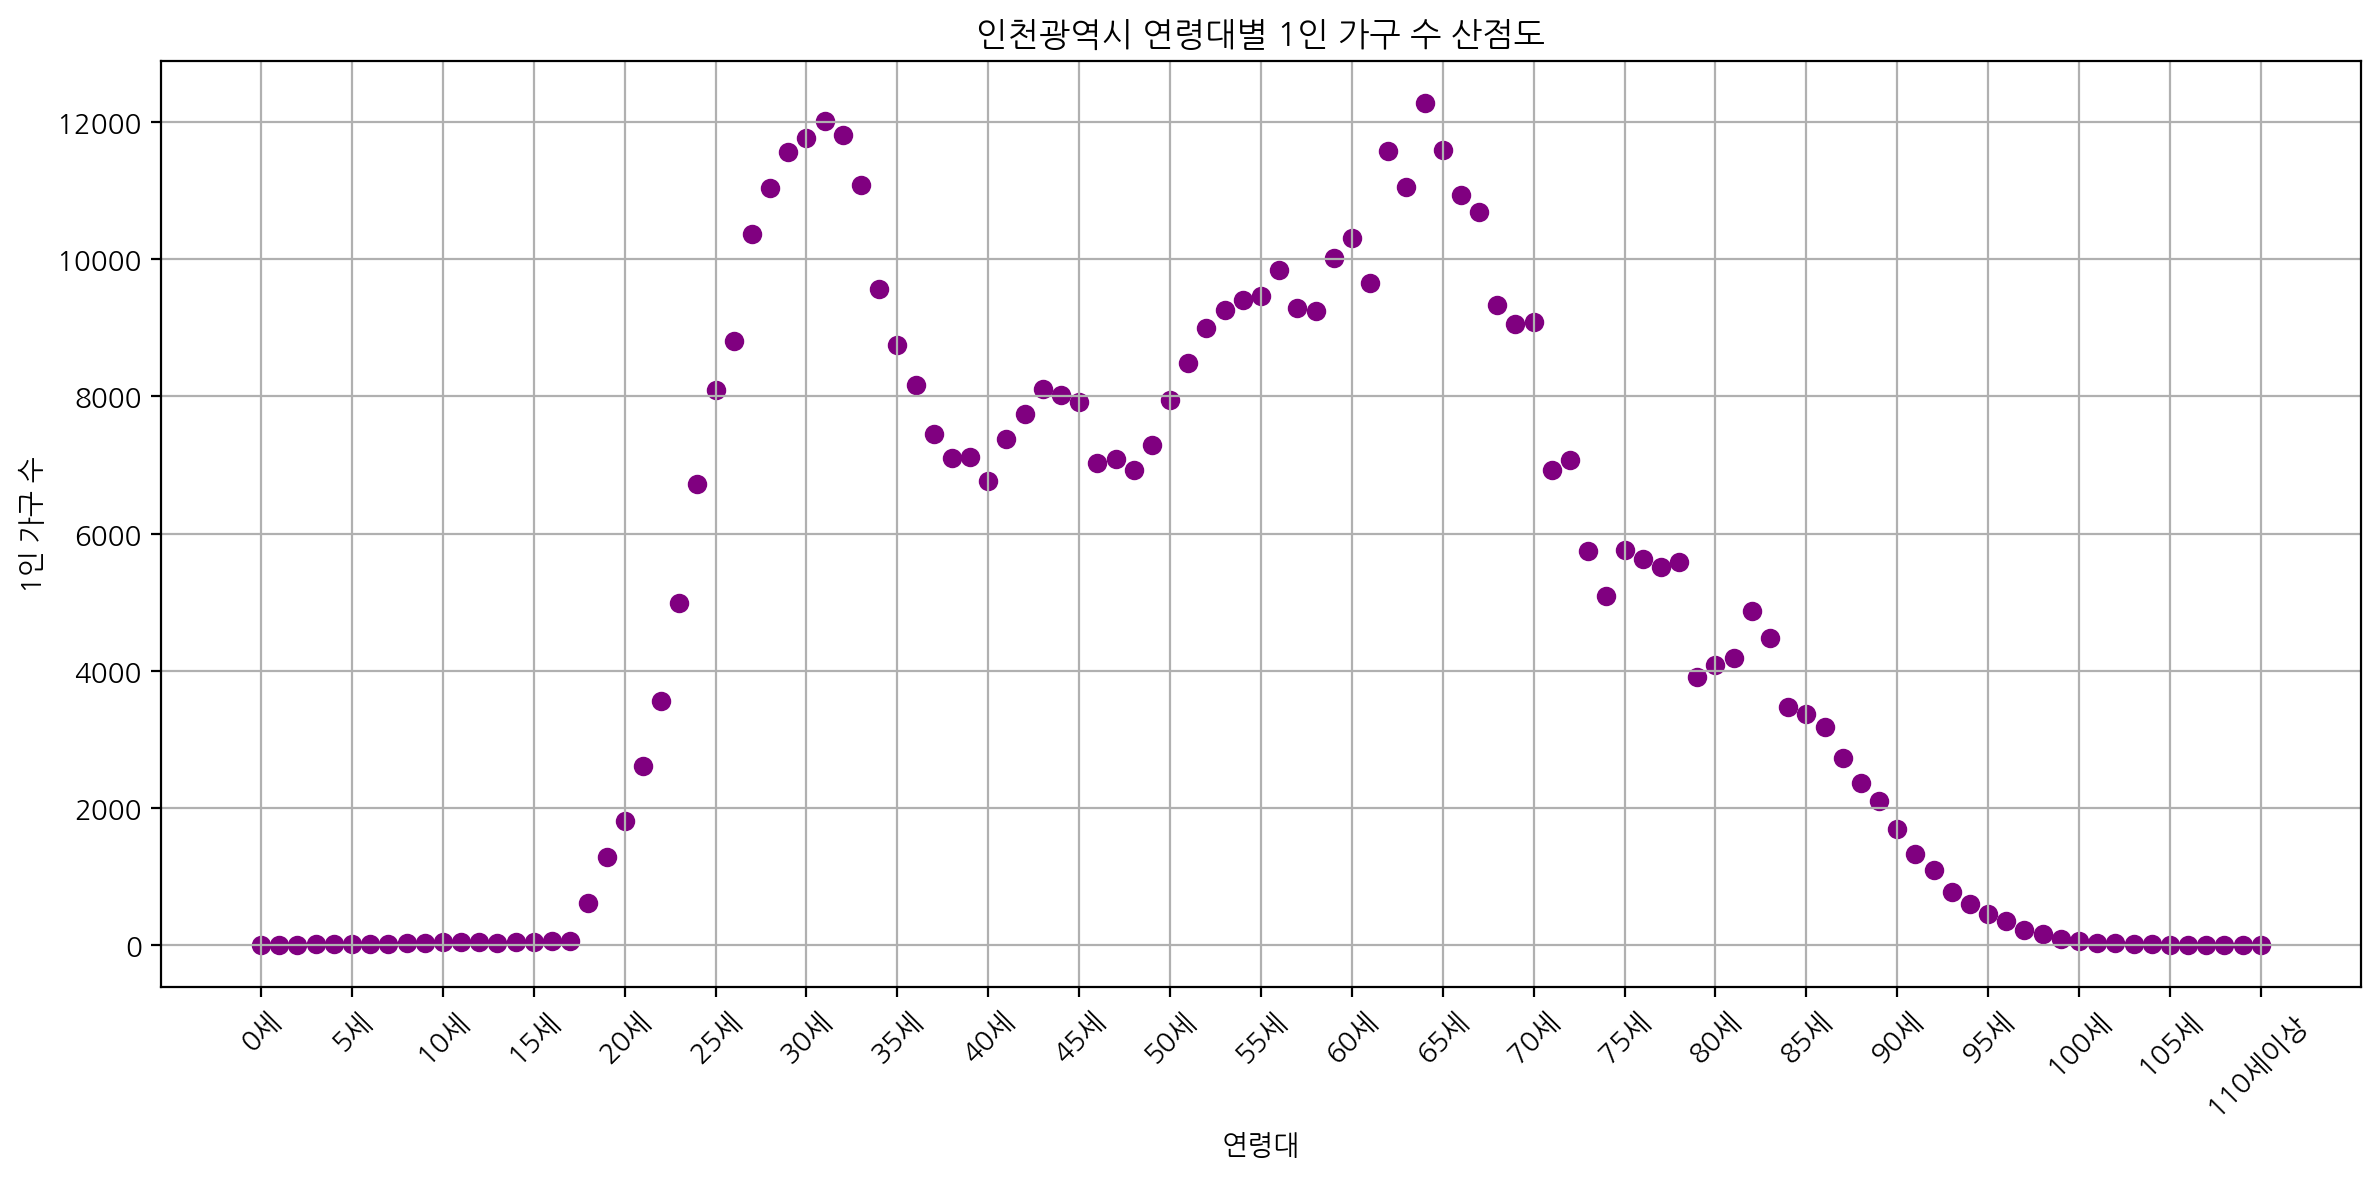

In [67]:
import matplotlib.pyplot as plt

# 인천광역시 데이터만 필터링
incheon_df = df[df["시도명"] == "인천광역시"]

# 연령대별 남자/여자 컬럼 추출
age_columns = [col for col in df.columns if '세' in col and ('남자' in col or '여자' in col)]

# 중복 없는 연령대 이름만 추출 (예: '20세', '25세', ..., '100세 이상')
age_groups = list(set(col[:-2] for col in age_columns))

# 연령대 정렬용 숫자 추출 함수 정의
def age_to_int(age):
    if '이상' in age:
        return int(age.replace('세이상', '').replace('세 이상', '').replace('세이 상', '').replace('세 이상', ''))
    else:
        return int(age.replace('세', ''))

# 정렬
age_groups_sorted = sorted(age_groups, key=age_to_int)

# 연령대별 남+여 합계 구하기
age_totals = []
for age in age_groups_sorted:
    male_col = age + '남자'
    female_col = age + '여자'
    if male_col in incheon_df.columns and female_col in incheon_df.columns:
        total = incheon_df[male_col].sum() + incheon_df[female_col].sum()
        age_totals.append(total)

# 산점도 그리기
plt.figure(figsize=(12, 6))
plt.scatter(age_groups_sorted, age_totals, color='purple')
plt.title('인천광역시 연령대별 1인 가구 수 산점도')
plt.xlabel('연령대')
plt.ylabel('1인 가구 수')

# x축 레이블 일부만 표시
plt.xticks(ticks=range(0, len(age_groups_sorted), 5),
           labels=age_groups_sorted[::5],
           rotation=45,
           fontsize=10)

plt.grid(True)
plt.tight_layout()
plt.show()

-> 가장 많은 1인 가구 수와 그에 해당하는 연령대 구하기

In [54]:
max_index = age_totals.index(max(age_totals))
most_common_age = age_groups_sorted[max_index]
most_common_total = age_totals[max_index]

print(f"✅ 인천광역시에서 1인 가구 수가 가장 많은 연령대는 '{most_common_age}'이며, 총 {most_common_total}가구입니다.")

✅ 인천광역시에서 1인 가구 수가 가장 많은 연령대는 '64세'이며, 총 12271가구입니다.


-> csv 파일에서 부산광역시만 분류

In [55]:
busan_df = df[df['시도명'] == '부산광역시']
busan_df

,시도명,시군구명,읍면동명,계,남자,여자,0세남자,1세남자,2세남자,3세남자,...,101세여자,102세여자,103세여자,104세여자,105세여자,106세여자,107세여자,108세여자,109세여자,110세이상 여자
426,부산광역시,중구,중앙동,2067,923,1144,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
427,부산광역시,중구,동광동,1025,556,469,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
428,부산광역시,중구,대청동,2079,945,1134,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
429,부산광역시,중구,보수동,3731,1686,2045,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
430,부산광역시,중구,부평동,1662,772,890,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,부산광역시,기장군,기장읍,11878,5531,6347,0,0,0,0,...,1,2,0,0,0,0,0,0,1,0
628,부산광역시,기장군,장안읍,2806,1673,1133,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
629,부산광역시,기장군,정관읍,9623,5089,4534,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
630,부산광역시,기장군,일광읍,4512,2259,2253,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


-> 부산광역시 남녀 비율 계산

In [56]:
busan_df['지역'] = busan_df['시군구명'] + ' ' + busan_df['읍면동명']

<ipython-input-56-f3743f44e60a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  busan_df['지역'] = busan_df['시군구명'] + ' ' + busan_df['읍면동명']


In [57]:
# 총 인구 컬럼 추가 (남자 + 여자)
busan_df['계'] = busan_df['남자'] + busan_df['여자']

<ipython-input-57-6c6f55be2ae2>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  busan_df['계'] = busan_df['남자'] + busan_df['여자']


In [58]:
# 남자와 여자 인구 총합 계산
male_total = busan_df['남자'].sum()
female_total = busan_df['여자'].sum()

In [59]:
# 비율 계산
total = male_total + female_total
male_ratio = male_total / total
female_ratio = female_total / total

In [61]:
print("✅ 부산광역시 남녀 비율")
print(f"남자 비율: {male_ratio:.3f}")
print(f"여자 비율: {female_ratio:.3f}")

✅ 부산광역시 남녀 비율
남자 비율: 0.468
여자 비율: 0.532


-> 부산광역시 남녀 비율 원그래프 시각화

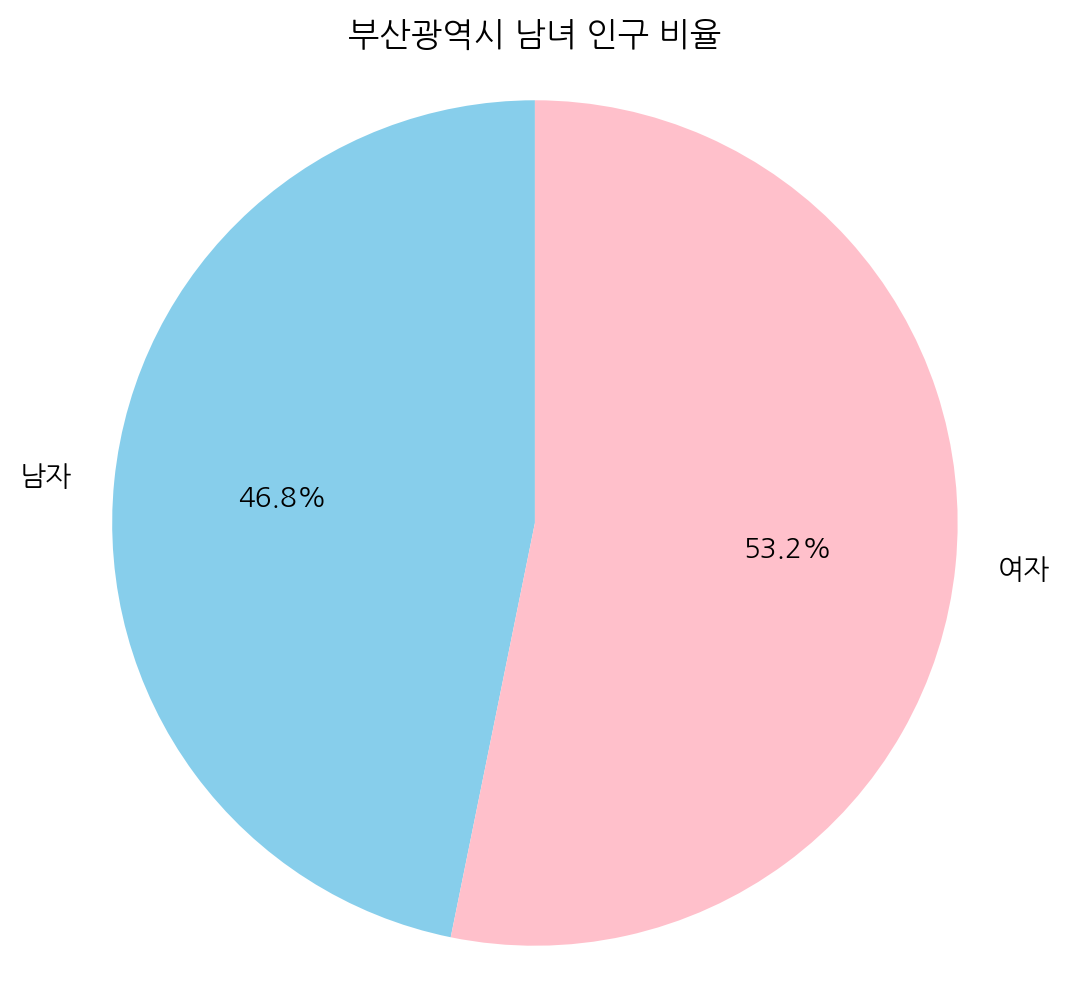

In [62]:
# 원 그래프 시각화
plt.figure(figsize=(6,6))
plt.pie([male_ratio, female_ratio],
        labels=['남자', '여자'],
        autopct='%.1f%%',
        startangle=90,
        colors=['skyblue', 'pink'])
plt.title('부산광역시 남녀 인구 비율')
plt.axis('equal')  # 원형 유지
plt.show()

-> 부산광역시에서 1인 가구 수가 가장 많은 지역 출력

In [65]:
# 부산광역시 데이터만 필터링
busan_df = df[df["시도명"] == "부산광역시"]

# '계' 값이 가장 큰 행의 인덱스 찾기
max_index = busan_df["계"].idxmax()

# 해당 행의 정보 추출
top_busan = busan_df.loc[max_index, ["시군구명", "읍면동명", "계"]]

# 결과 출력
print("✅ 부산광역시에서 1인 가구 수가 가장 많은 지역:")
print(top_busan)

✅ 부산광역시에서 1인 가구 수가 가장 많은 지역:
시군구명      기장군
읍면동명      기장읍
계       11878
Name: 627, dtype: object


-> 전체 연령대의 1인 가구수 산점도 그래프 시각화

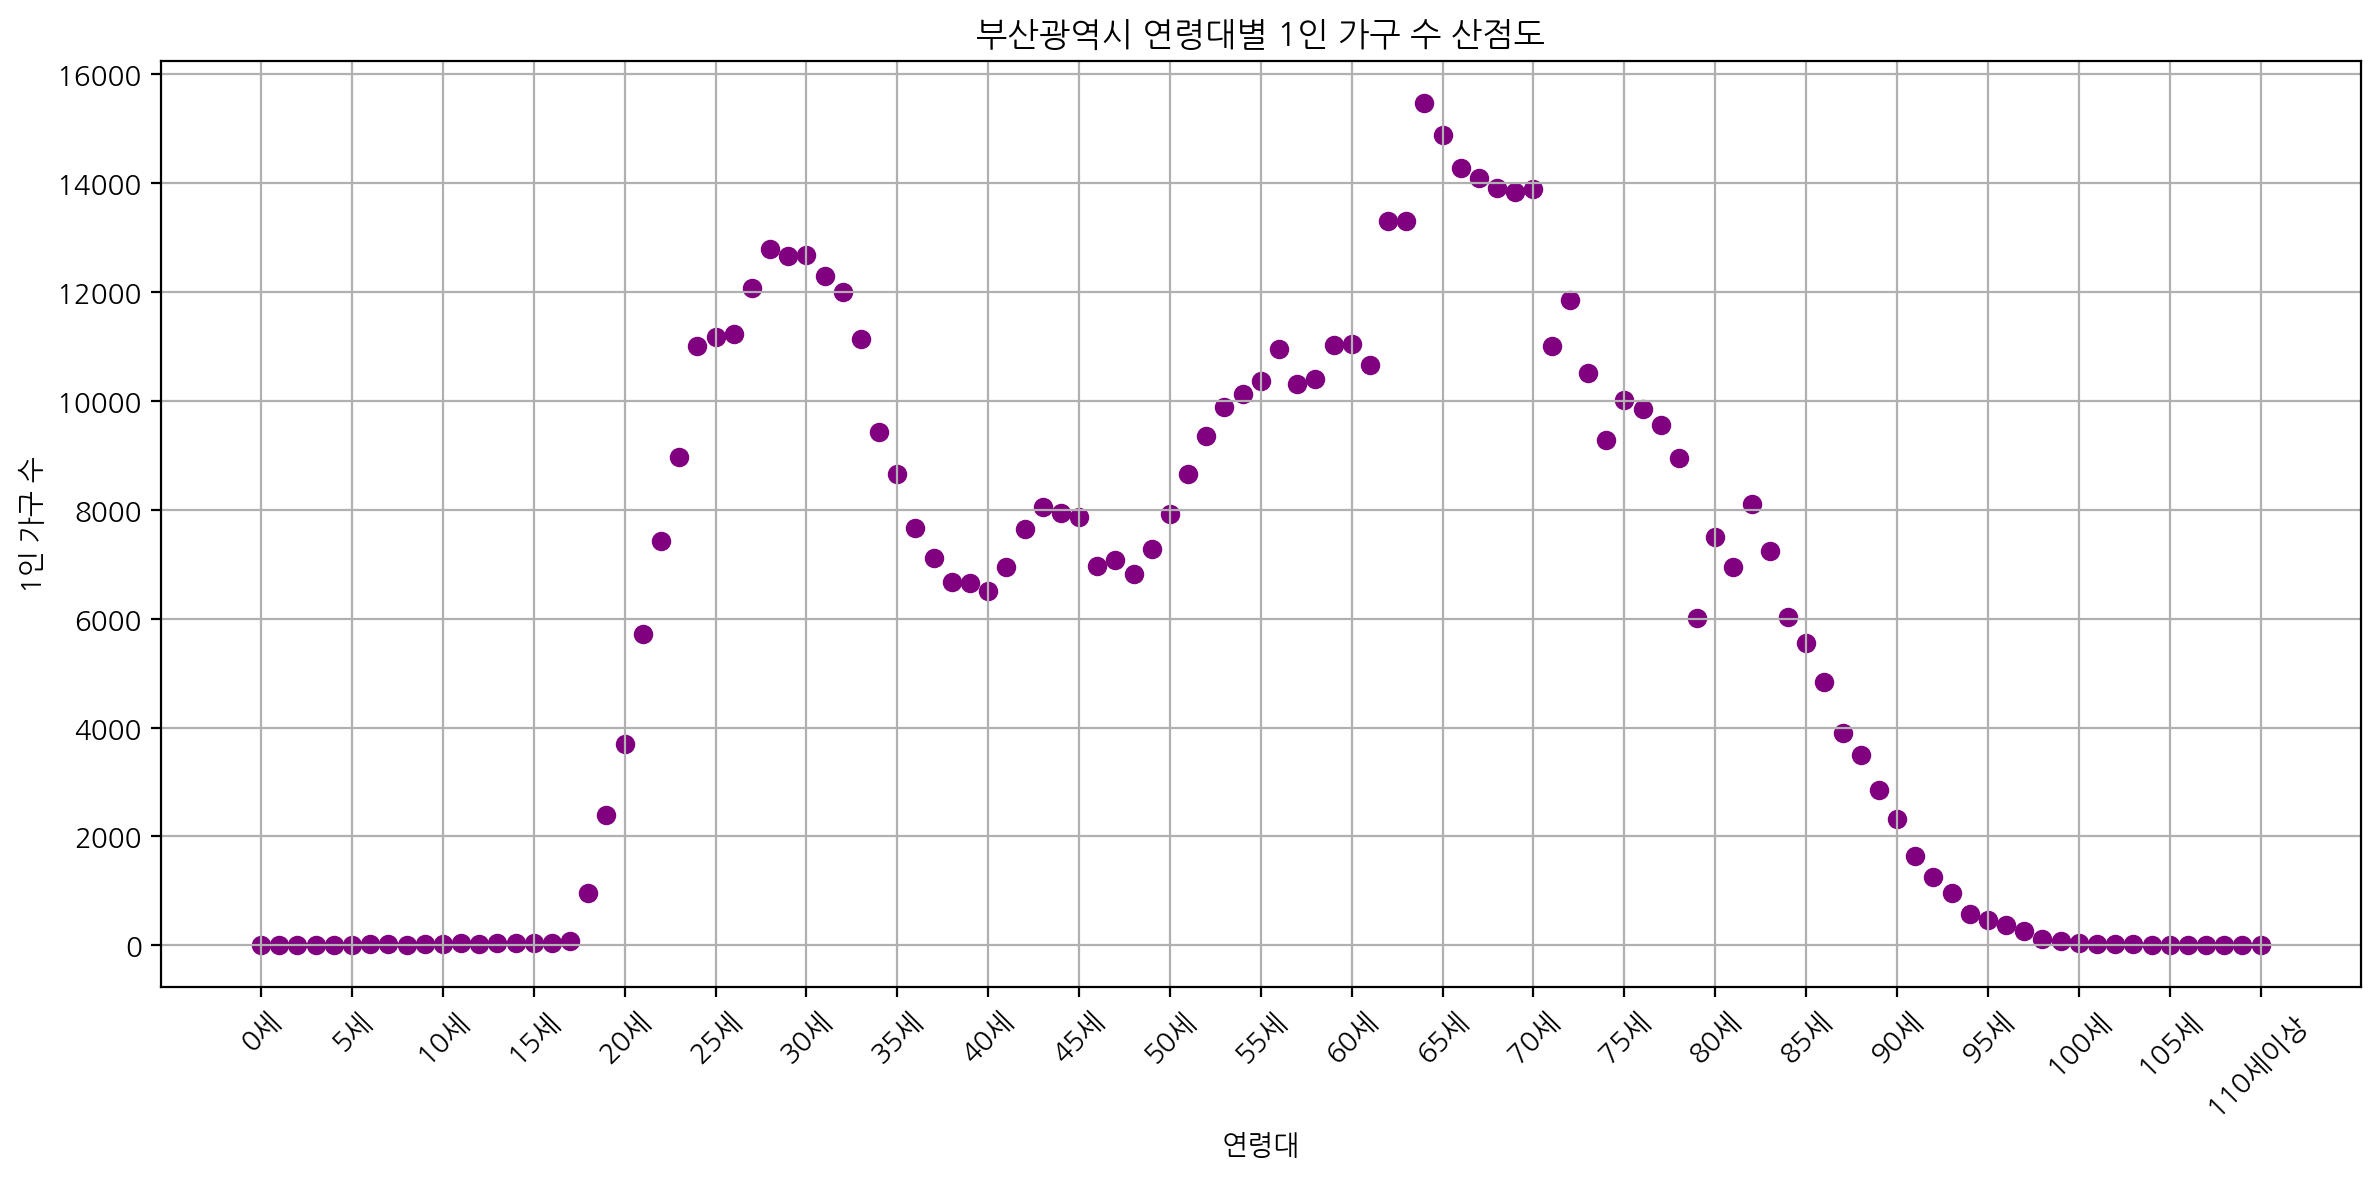

In [69]:
import matplotlib.pyplot as plt

# 부산광역시 데이터만 필터링
busan_df = df[df["시도명"] == "부산광역시"]

# 연령대별 남자/여자 컬럼 추출
age_columns = [col for col in df.columns if '세' in col and ('남자' in col or '여자' in col)]

# 중복 없는 연령대 이름만 추출 (예: '20세', '25세', ..., '100세 이상')
age_groups = list(set(col[:-2] for col in age_columns))

# 연령대 정렬용 숫자 추출 함수 정의
def age_to_int(age):
    if '이상' in age:
        return int(age.replace('세이상', '').replace('세 이상', '').replace('세이 상', '').replace('세 이상', ''))
    else:
        return int(age.replace('세', ''))

# 정렬
age_groups_sorted = sorted(age_groups, key=age_to_int)

# 연령대별 남+여 합계 구하기
age_totals = []
for age in age_groups_sorted:
    male_col = age + '남자'
    female_col = age + '여자'
    if male_col in busan_df.columns and female_col in busan_df.columns:
        total = busan_df[male_col].sum() + busan_df[female_col].sum()
        age_totals.append(total)

# 산점도 그리기
plt.figure(figsize=(12, 6))
plt.scatter(age_groups_sorted, age_totals, color='purple')
plt.title('부산광역시 연령대별 1인 가구 수 산점도')
plt.xlabel('연령대')
plt.ylabel('1인 가구 수')

# x축 레이블 일부만 표시
plt.xticks(ticks=range(0, len(age_groups_sorted), 5),
           labels=age_groups_sorted[::5],
           rotation=45,
           fontsize=10)

plt.grid(True)
plt.tight_layout()
plt.show()

-> 가장 많은 1인 가구 수와 그에 해당하는 연령대 구하기

In [70]:
max_index = age_totals.index(max(age_totals))
most_common_age = age_groups_sorted[max_index]
most_common_total = age_totals[max_index]

print(f"✅ 부산광역시에서 1인 가구 수가 가장 많은 연령대는 '{most_common_age}'이며, 총 {most_common_total}가구입니다.")

✅ 부산광역시에서 1인 가구 수가 가장 많은 연령대는 '64세'이며, 총 15469가구입니다.


-> csv 파일에서 대구광역시만 분류

In [71]:
daegu_df = df[df['시도명'] == '대구광역시']
daegu_df

,시도명,시군구명,읍면동명,계,남자,여자,0세남자,1세남자,2세남자,3세남자,...,101세여자,102세여자,103세여자,104세여자,105세여자,106세여자,107세여자,108세여자,109세여자,110세이상 여자
632,대구광역시,중구,동인동,3512,1795,1717,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
633,대구광역시,중구,삼덕동,2892,1451,1441,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
634,대구광역시,중구,성내1동,2928,1351,1577,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
635,대구광역시,중구,성내2동,2772,1325,1447,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
636,대구광역시,중구,성내3동,1913,1018,895,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,대구광역시,군위군,부계면,722,392,330,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
780,대구광역시,군위군,우보면,738,373,365,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
781,대구광역시,군위군,의흥면,788,377,411,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
782,대구광역시,군위군,산성면,475,235,240,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


-> 대구광역시 남녀 비율 계산

In [72]:
daegu_df['지역'] = daegu_df['시군구명'] + ' ' + daegu_df['읍면동명']

<ipython-input-72-6efc4dc40586>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daegu_df['지역'] = daegu_df['시군구명'] + ' ' + daegu_df['읍면동명']


In [73]:
# 총 인구 컬럼 추가 (남자 + 여자)
daegu_df['계'] = daegu_df['남자'] + daegu_df['여자']

<ipython-input-73-0b8c1598cec1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daegu_df['계'] = daegu_df['남자'] + daegu_df['여자']


In [74]:
# 남자와 여자 인구 총합 계산
male_total = daegu_df['남자'].sum()
female_total = daegu_df['여자'].sum()

In [75]:
# 비율 계산
total = male_total + female_total
male_ratio = male_total / total
female_ratio = female_total / total

In [76]:
print("✅ 대구광역시 남녀 비율")
print(f"남자 비율: {male_ratio:.3f}")
print(f"여자 비율: {female_ratio:.3f}")

✅ 대구광역시 남녀 비율
남자 비율: 0.475
여자 비율: 0.525


-> 대구광역시 남녀 비율 원그래프 시각화

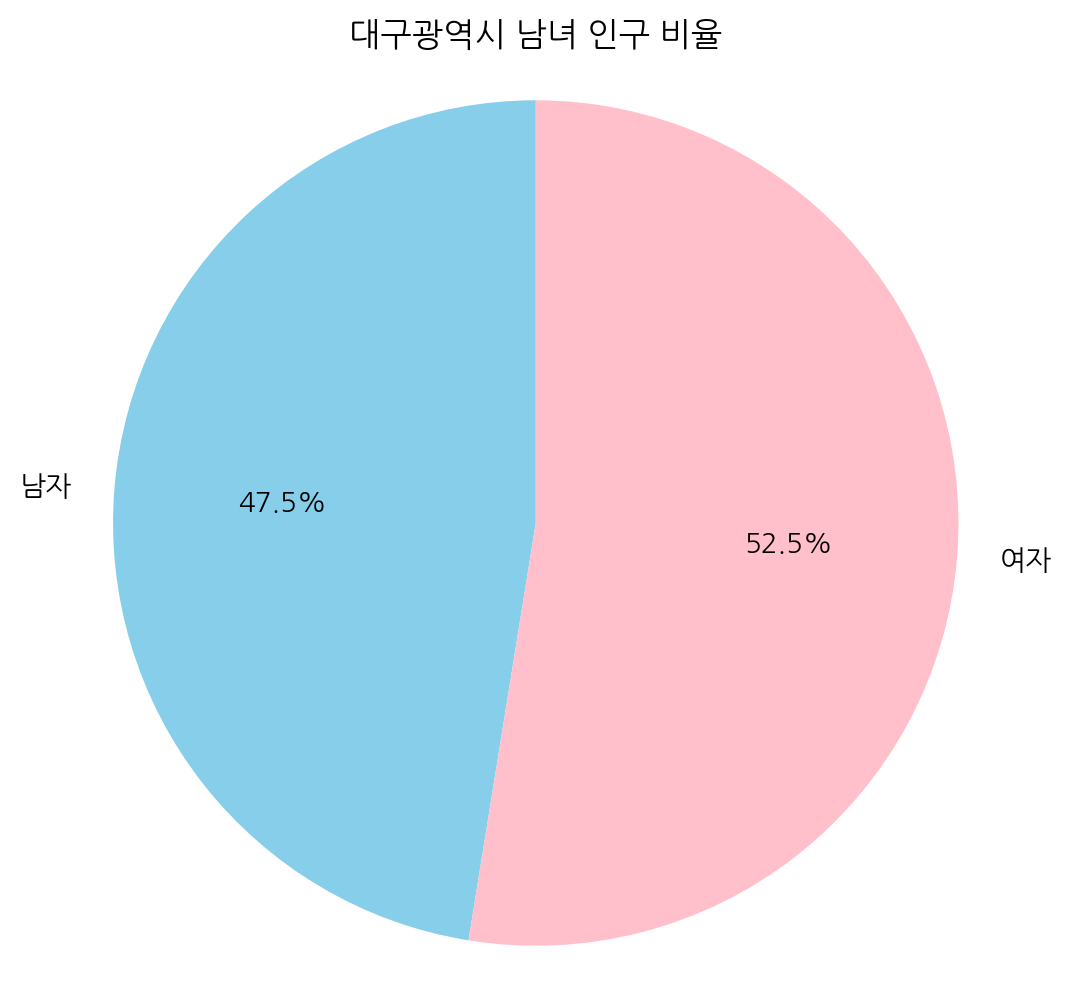

In [77]:
# 원 그래프 시각화
plt.figure(figsize=(6,6))
plt.pie([male_ratio, female_ratio],
        labels=['남자', '여자'],
        autopct='%.1f%%',
        startangle=90,
        colors=['skyblue', 'pink'])
plt.title('대구광역시 남녀 인구 비율')
plt.axis('equal')  # 원형 유지
plt.show()

-> 대구광역시에서 1인 가구 수가 가장 많은 지역 출력

In [79]:
# 대구광역시 데이터만 필터링
daegu_df = df[df["시도명"] == "대구광역시"]

# '계' 값이 가장 큰 행의 인덱스 찾기
max_index = daegu_df["계"].idxmax()

# 해당 행의 정보 추출
top_daegu = daegu_df.loc[max_index, ["시군구명", "읍면동명", "계"]]

# 결과 출력
print("✅ 대구광역시에서 1인 가구 수가 가장 많은 지역:")
print(top_daegu)

✅ 대구광역시에서 1인 가구 수가 가장 많은 지역:
시군구명      달서구
읍면동명      신당동
계       10853
Name: 752, dtype: object


-> 전체 연령대의 1인 가구수 산점도 그래프 시각화

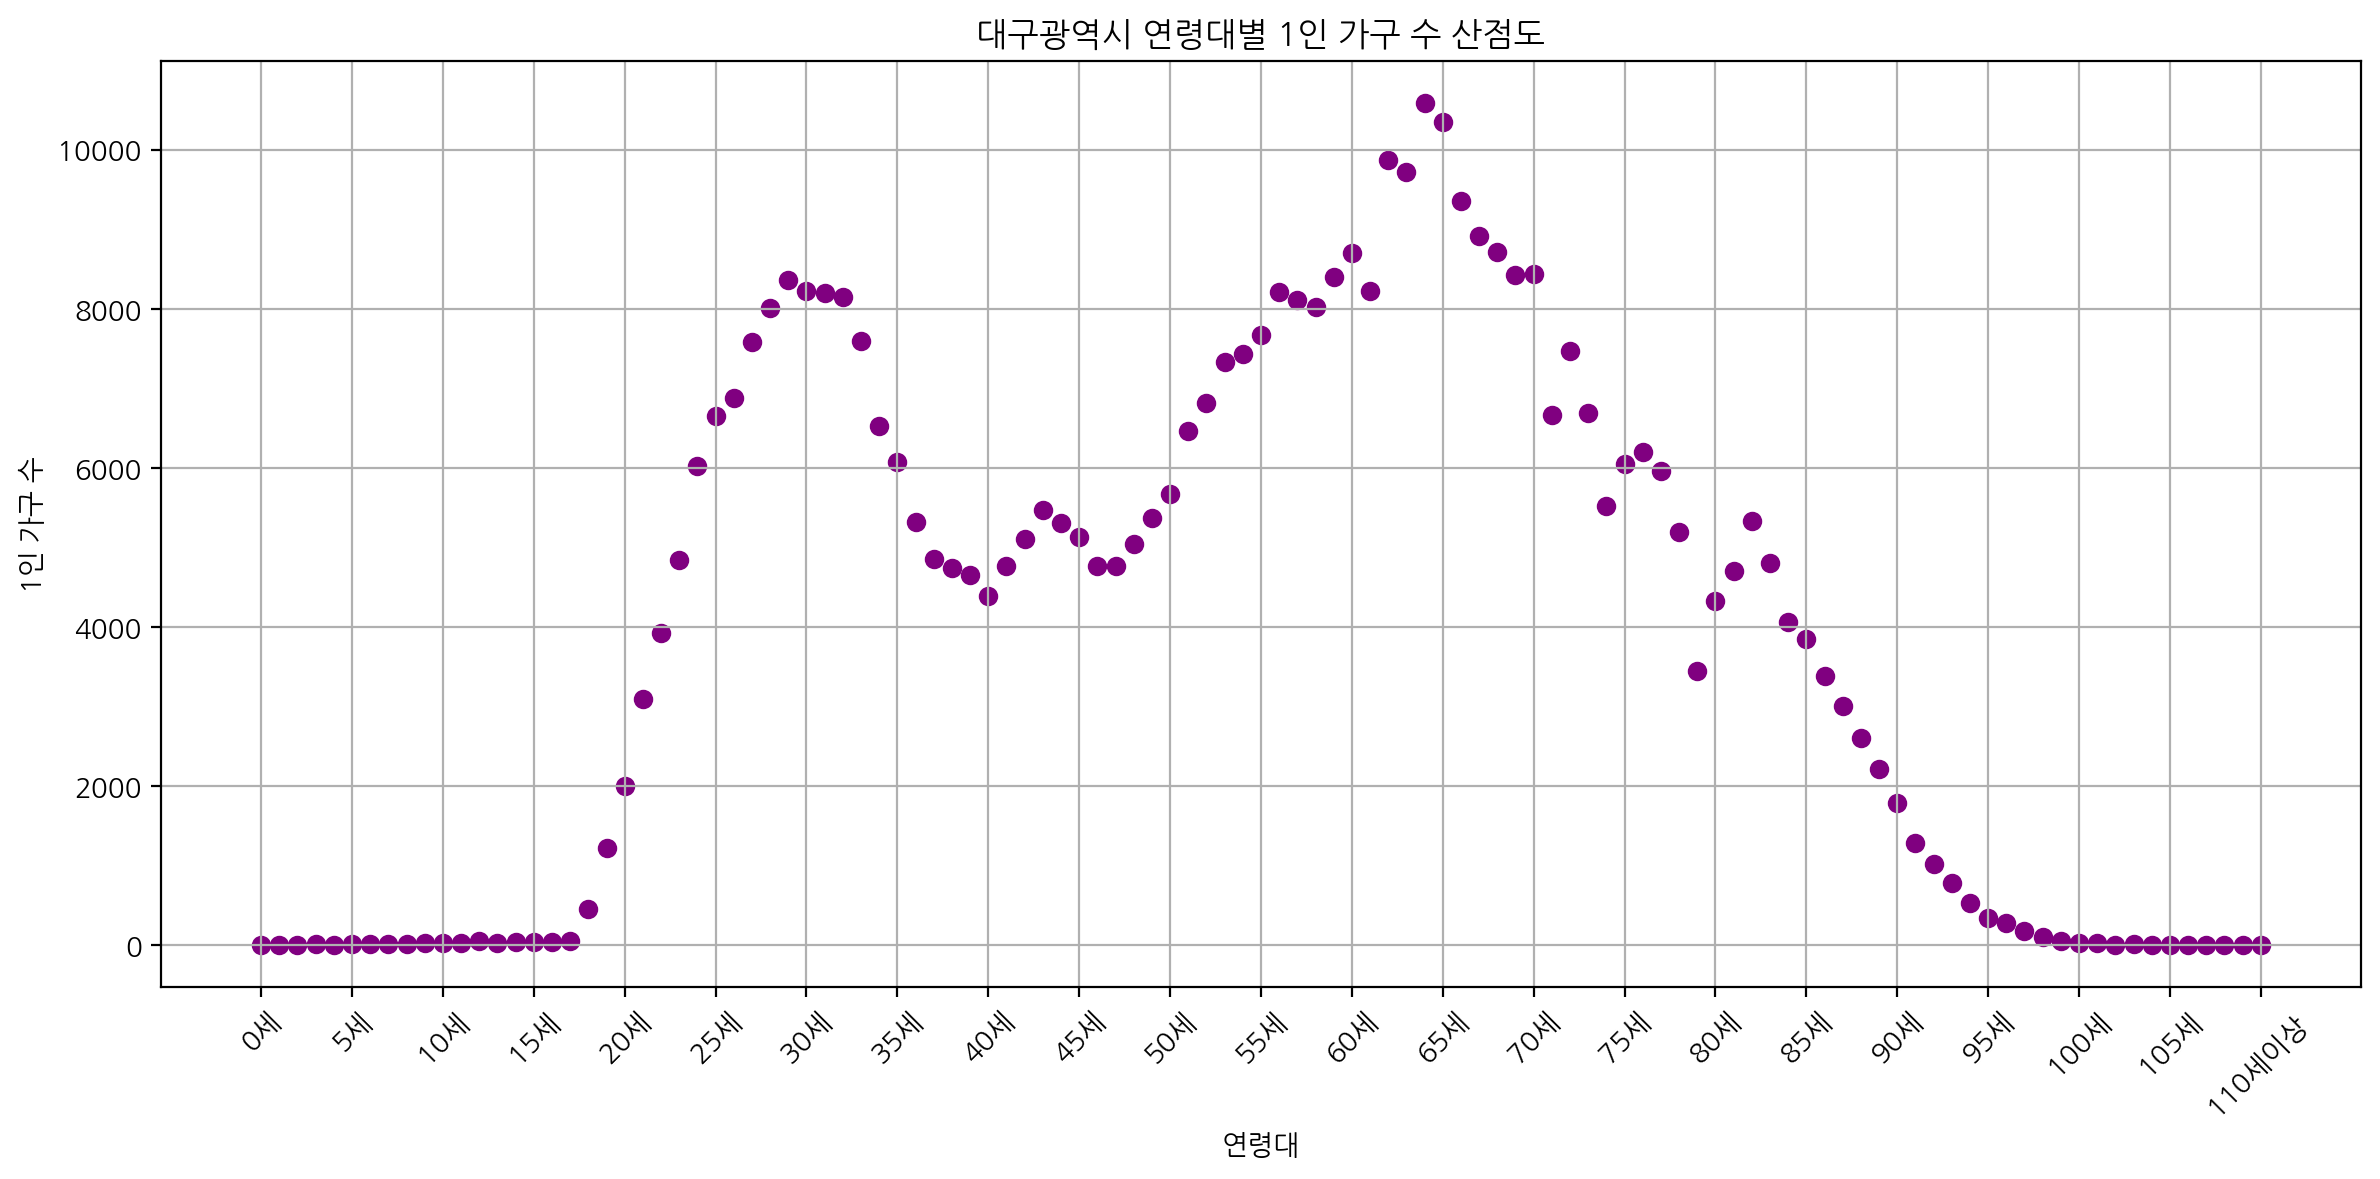

In [80]:
import matplotlib.pyplot as plt

# 대구광역시 데이터만 필터링
daegu_df = df[df["시도명"] == "대구광역시"]

# 연령대별 남자/여자 컬럼 추출
age_columns = [col for col in df.columns if '세' in col and ('남자' in col or '여자' in col)]

# 중복 없는 연령대 이름만 추출 (예: '20세', '25세', ..., '100세 이상')
age_groups = list(set(col[:-2] for col in age_columns))

# 연령대 정렬용 숫자 추출 함수 정의
def age_to_int(age):
    if '이상' in age:
        return int(age.replace('세이상', '').replace('세 이상', '').replace('세이 상', '').replace('세 이상', ''))
    else:
        return int(age.replace('세', ''))

# 정렬
age_groups_sorted = sorted(age_groups, key=age_to_int)

# 연령대별 남+여 합계 구하기
age_totals = []
for age in age_groups_sorted:
    male_col = age + '남자'
    female_col = age + '여자'
    if male_col in daegu_df.columns and female_col in daegu_df.columns:
        total = daegu_df[male_col].sum() + daegu_df[female_col].sum()
        age_totals.append(total)

# 산점도 그리기
plt.figure(figsize=(12, 6))
plt.scatter(age_groups_sorted, age_totals, color='purple')
plt.title('대구광역시 연령대별 1인 가구 수 산점도')
plt.xlabel('연령대')
plt.ylabel('1인 가구 수')

# x축 레이블 일부만 표시
plt.xticks(ticks=range(0, len(age_groups_sorted), 5),
           labels=age_groups_sorted[::5],
           rotation=45,
           fontsize=10)

plt.grid(True)
plt.tight_layout()
plt.show()

In [81]:
max_index = age_totals.index(max(age_totals))
most_common_age = age_groups_sorted[max_index]
most_common_total = age_totals[max_index]

print(f"✅ 대구광역시에서 1인 가구 수가 가장 많은 연령대는 '{most_common_age}'이며, 총 {most_common_total}가구입니다.")

✅ 대구광역시에서 1인 가구 수가 가장 많은 연령대는 '64세'이며, 총 10581가구입니다.
